# Multi-area sampled activity + structural / random eigenspectra

Set the **two-area** parameters (as in `Eigenspectra_scheme.ipynb`), simulate the rate
dynamics `dx/dt = -x + W φ(x)`, and show in one figure:

- **main panel**  : 5 randomly-sampled neuron traces per area (**10 in total**),
  each drawn in its own colour (style of `Intrinsical_fluctuation.ipynb`).
- **inset**       : eigenspectrum of `W` decomposed as `W = S + R`
  - **red**   = structural-part eigenvalues (the rank-2 outliers of `S = E[W]`)
  - **blue**  = random-part eigenvalues (`R = W - S`, the bulk)
  - **black dashed line** = stability boundary at `Re(λ) = 1`

Building blocks (`AreaParams`, `MultiAreaParams`, connectivity, mean connectivity, theory) are
reused verbatim from `Eigenspectra_scheme.ipynb`; the per-area sampling simulator
`simulate_rate_network_by_area` is reused from `Multi-area_circuit_EI_sparse_case_study.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.lines import Line2D
from scipy.sparse import csr_matrix
from dataclasses import dataclass
from typing import Any, Dict, List, Mapping, Optional, Sequence, Tuple

In [2]:
# ============================================================
#  Parameters
# ============================================================

@dataclass(frozen=True)
class AreaParams:
    """
    Parameters for one brain area.

    N      : number of neurons in this area
    s      : local sparsity, defined by C_i / N_i
    f_exc  : fraction of excitatory neurons in this area
    J_exc  : local excitatory synaptic weight in this area
    g_inh  : local inhibitory strength ratio
    """
    N: int
    s: float
    f_exc: float
    J_exc: float
    g_inh: float


@dataclass(frozen=True)
class MultiAreaParams:
    """
    Parameters for the full multi-area network.

    s_cross[src, tgt] : cross-area sparsity from src to tgt
    J_cross[src, tgt] : cross-area excitatory weight from src to tgt

    activation: "tanh" or "threshold_linear"
    phi_max   : only used if activation == "threshold_linear"
    gamma     : threshold offset in phi(x) = max(0, x + gamma)
    """
    areas: Tuple[AreaParams, ...]
    s_cross: np.ndarray
    J_cross: np.ndarray
    allow_autapses: bool
    activation: str
    phi_max: float
    gamma: float
    dt: float
    T: float
    seed: int = 0


# ============================================================
#  Activation
# ============================================================

def phi(x: np.ndarray, p: MultiAreaParams) -> np.ndarray:
    x = np.asarray(x, dtype=float)

    if p.activation == "tanh":
        return np.tanh(x) + 1.0

    if p.activation == "threshold_linear":
        y = np.maximum(0.0, x + p.gamma)
        if np.isfinite(p.phi_max):
            y = np.minimum(p.phi_max, y)
        return y

    raise ValueError(f"Unknown activation = {p.activation}")


def phi_prime(x: np.ndarray, p: MultiAreaParams) -> np.ndarray:
    x = np.asarray(x, dtype=float)

    if p.activation == "tanh":
        y = np.tanh(x)
        return 1.0 - y * y

    if p.activation == "threshold_linear":
        g = ((x + p.gamma) >= 0.0).astype(float)
        if np.isfinite(p.phi_max):
            g = g * ((x + p.gamma) < p.phi_max)
        return g

    raise ValueError(f"Unknown activation = {p.activation}")


# ============================================================
#  Population bookkeeping
# ============================================================

def population_info(p: MultiAreaParams) -> Dict[str, Any]:
    pops = []
    pop_sizes = []
    pop_slices = {}
    area_slices = {}
    area_stats = []

    start = 0
    for area_id, ap in enumerate(p.areas):
        N_E = int(round(ap.f_exc * ap.N))
        N_I = ap.N - N_E

        if N_E < 0 or N_I < 0:
            raise ValueError(f"Area {area_id}: invalid E/I split")

        C = int(round(ap.s * ap.N))
        C_E = int(round(ap.f_exc * C))
        C_I = C - C_E

        e_slice = slice(start, start + N_E)
        pops.append((area_id, "E"))
        pop_slices[(area_id, "E")] = e_slice
        pop_sizes.append(N_E)
        start += N_E

        i_slice = slice(start, start + N_I)
        pops.append((area_id, "I"))
        pop_slices[(area_id, "I")] = i_slice
        pop_sizes.append(N_I)
        start += N_I

        area_slices[area_id] = slice(e_slice.start, i_slice.stop)

        area_stats.append(
            {
                "area_id": area_id,
                "N": ap.N,
                "N_E": N_E,
                "N_I": N_I,
                "C": C,
                "C_E": C_E,
                "C_I": C_I,
                "J_E": ap.J_exc,
                "J_I": -ap.g_inh * ap.J_exc,
            }
        )

    return {
        "pops": pops,
        "pop_sizes": np.asarray(pop_sizes, dtype=int),
        "N_total": start,
        "pop_slices": pop_slices,
        "area_slices": area_slices,
        "area_stats": area_stats,
    }


def _validate_params(p: MultiAreaParams) -> None:
    A = len(p.areas)

    if p.s_cross.shape != (A, A):
        raise ValueError(f"s_cross must have shape ({A}, {A})")
    if p.J_cross.shape != (A, A):
        raise ValueError(f"J_cross must have shape ({A}, {A})")

    for area_id, ap in enumerate(p.areas):
        if ap.N <= 0:
            raise ValueError(f"Area {area_id}: N must be positive")
        if not (0.0 <= ap.s <= 1.0):
            raise ValueError(f"Area {area_id}: s must be in [0, 1]")
        if not (0.0 <= ap.f_exc <= 1.0):
            raise ValueError(f"Area {area_id}: f_exc must be in [0, 1]")

    if np.any(p.s_cross < 0.0) or np.any(p.s_cross > 1.0):
        raise ValueError("All s_cross entries must be in [0, 1]")


def _candidate_pool(indices: np.ndarray, target_idx: int, allow_autapses: bool) -> np.ndarray:
    if allow_autapses or len(indices) == 0:
        return indices

    if indices[0] <= target_idx <= indices[-1]:
        return indices[indices != target_idx]
    return indices

In [3]:
# ============================================================
#  Connectivity
# ============================================================

def build_multi_area_connectivity(p: MultiAreaParams) -> Tuple[csr_matrix, Dict[str, Any]]:
    """
    Build the full sparse recurrent matrix W.
    Convention: W[i, j] = connection from neuron j to neuron i.
    """
    _validate_params(p)
    rng = np.random.default_rng(p.seed)
    info = population_info(p)

    A = len(p.areas)
    N_total = info["N_total"]
    pop_slices = info["pop_slices"]
    area_stats = info["area_stats"]

    rows: List[int] = []
    cols: List[int] = []
    data: List[float] = []

    for tgt_area in range(A):
        stat_t = area_stats[tgt_area]
        tgt_all = np.arange(info["area_slices"][tgt_area].start, info["area_slices"][tgt_area].stop)
        tgt_exc = np.arange(pop_slices[(tgt_area, "E")].start, pop_slices[(tgt_area, "E")].stop)
        tgt_inh = np.arange(pop_slices[(tgt_area, "I")].start, pop_slices[(tgt_area, "I")].stop)

        C_E_local = stat_t["C_E"]
        C_I_local = stat_t["C_I"]
        w_E_local = stat_t["J_E"]
        w_I_local = stat_t["J_I"]

        for i_tgt in tgt_all:
            exc_pool = _candidate_pool(tgt_exc, i_tgt, p.allow_autapses)
            inh_pool = _candidate_pool(tgt_inh, i_tgt, p.allow_autapses)

            if C_E_local > len(exc_pool):
                raise ValueError(
                    f"Area {tgt_area}: local C_E={C_E_local} exceeds available local excitatory pool={len(exc_pool)}"
                )
            if C_I_local > len(inh_pool):
                raise ValueError(
                    f"Area {tgt_area}: local C_I={C_I_local} exceeds available local inhibitory pool={len(inh_pool)}"
                )

            if C_E_local > 0:
                pre_exc = rng.choice(exc_pool, size=C_E_local, replace=False)
                rows.extend([i_tgt] * C_E_local)
                cols.extend(pre_exc.tolist())
                data.extend([w_E_local] * C_E_local)

            if C_I_local > 0:
                pre_inh = rng.choice(inh_pool, size=C_I_local, replace=False)
                rows.extend([i_tgt] * C_I_local)
                cols.extend(pre_inh.tolist())
                data.extend([w_I_local] * C_I_local)

            for src_area in range(A):
                if src_area == tgt_area:
                    continue

                src_exc = np.arange(pop_slices[(src_area, "E")].start, pop_slices[(src_area, "E")].stop)
                if len(src_exc) == 0:
                    continue

                s_ij = float(p.s_cross[src_area, tgt_area])
                if s_ij <= 0.0:
                    continue

                C_cross = int(round(s_ij * len(src_exc)))
                if C_cross == 0:
                    continue
                if C_cross > len(src_exc):
                    raise ValueError(
                        f"Cross ({src_area}->{tgt_area}): C_cross={C_cross} exceeds source excitatory pool={len(src_exc)}"
                    )

                pre_cross = rng.choice(src_exc, size=C_cross, replace=False)
                w_cross = float(p.J_cross[src_area, tgt_area])

                rows.extend([i_tgt] * C_cross)
                cols.extend(pre_cross.tolist())
                data.extend([w_cross] * C_cross)

    W = csr_matrix(
        (
            np.asarray(data, dtype=float),
            (np.asarray(rows, dtype=int), np.asarray(cols, dtype=int)),
        ),
        shape=(N_total, N_total),
    )

    meta = {
        "N_total": N_total,
        "pops": info["pops"],
        "pop_sizes": info["pop_sizes"],
        "pop_slices": pop_slices,
        "area_slices": info["area_slices"],
        "area_stats": area_stats,
        "nnz": W.nnz,
    }
    return W, meta


def lift_population_values_to_neurons(values: np.ndarray, p: MultiAreaParams) -> np.ndarray:
    info = population_info(p)
    pops = info["pops"]
    pop_slices = info["pop_slices"]
    N_total = info["N_total"]

    out = np.empty(N_total, dtype=float)
    for k, (area_id, cell_type) in enumerate(pops):
        out[pop_slices[(area_id, cell_type)]] = values[k]
    return out

In [4]:
# ============================================================
#  Structural mean connectivity  S = E[W]  (dense)
# ============================================================

def build_mean_connectivity_dense(p: MultiAreaParams) -> np.ndarray:
    """
    Build the mean connectivity matrix S = E[W] numerically
    from the same block means used in your note.

    Convention:
      W[i, j] = connection from neuron j to neuron i

    We use the same simplified mean structure as in the note:
    - within one area:
        source E projects with mean  J_exc * C_E / N_E
        source I projects with mean -g*J_exc * C_I / N_I
      onto both E and I targets in the same area
    - across areas:
        only source E projects, with mean J_cross * C_cross / N_E(src)
      onto all neurons in the target area
    """
    info = population_info(p)
    pop_slices = info["pop_slices"]
    area_slices = info["area_slices"]
    area_stats = info["area_stats"]
    N_total = info["N_total"]
    A = len(p.areas)

    S = np.zeros((N_total, N_total), dtype=float)

    for tgt in range(A):
        tgt_all = area_slices[tgt]

        for src in range(A):
            src_E = pop_slices[(src, "E")]
            src_I = pop_slices[(src, "I")]
            stat_s = area_stats[src]

            N_E_src = stat_s["N_E"]
            N_I_src = stat_s["N_I"]

            if src == tgt:
                # local E source mean
                mu_E = 0.0 if N_E_src == 0 else stat_s["J_E"] * stat_s["C_E"] / N_E_src
                # local I source mean
                mu_I = 0.0 if N_I_src == 0 else stat_s["J_I"] * stat_s["C_I"] / N_I_src

                S[tgt_all, src_E] = mu_E
                S[tgt_all, src_I] = mu_I

            else:
                # cross-area: only source E projects
                q = float(p.s_cross[src, tgt])
                C_cross = int(round(q * N_E_src))
                mu_cross = 0.0 if N_E_src == 0 else float(p.J_cross[src, tgt]) * C_cross / N_E_src

                S[tgt_all, src_E] = mu_cross
                S[tgt_all, src_I] = 0.0

    return S

In [5]:
# ============================================================
#  Theory: bulk radius  r_R = sqrt(rho(G))  and the two
#  structural roots (the outliers)
# ============================================================

def _candidate_pool_size(
    pop_size: int,
    target_belongs_to_source_pool: bool,
    allow_autapses: bool
) -> int:
    """
    Exact source pool size under your construction rule.
    """
    if allow_autapses:
        return pop_size
    return pop_size - 1 if target_belongs_to_source_pool else pop_size


def _variance_fixed_indegree_entry(weight: float, indegree: int, pool_size: int) -> float:
    """
    Exact single-entry variance for fixed in-degree sampling without replacement:
        P(conn) = indegree / pool_size
        Var(W_ij) = weight^2 * p * (1-p)
    """
    if pool_size <= 0:
        return np.nan
    if indegree < 0 or indegree > pool_size:
        return np.nan

    p_conn = indegree / pool_size
    return (weight ** 2) * p_conn * (1.0 - p_conn)


def build_random_variance_matrix_full_4x4(p: MultiAreaParams) -> np.ndarray:
    """
    Full 4x4 block variance matrix G for the two-area case.

    Population order:
        0: area0,E
        1: area0,I
        2: area1,E
        3: area1,I

    G_cd = alpha_c * g_cd^2 = n_c * Var(block_cd entry)
    """
    _validate_params(p)

    if len(p.areas) != 2:
        raise ValueError("Current implementation assumes exactly 2 areas.")

    info = population_info(p)
    st0, st1 = info["area_stats"]
    ap0, ap1 = p.areas

    N_E0, N_I0 = st0["N_E"], st0["N_I"]
    N_E1, N_I1 = st1["N_E"], st1["N_I"]

    C_E0, C_I0 = st0["C_E"], st0["C_I"]
    C_E1, C_I1 = st1["C_E"], st1["C_I"]

    C_0_to_1 = int(round(float(p.s_cross[0, 1]) * N_E0))
    C_1_to_0 = int(round(float(p.s_cross[1, 0]) * N_E1))

    J0 = ap0.J_exc
    J1 = ap1.J_exc
    JI0 = -ap0.g_inh * ap0.J_exc
    JI1 = -ap1.g_inh * ap1.J_exc
    J_0_to_1 = float(p.J_cross[0, 1])
    J_1_to_0 = float(p.J_cross[1, 0])

    row_sizes = np.array([N_E0, N_I0, N_E1, N_I1], dtype=float)
    G = np.zeros((4, 4), dtype=float)

    # row 0: target area0, E
    G[0, 0] = row_sizes[0] * _variance_fixed_indegree_entry(
        J0, C_E0,
        _candidate_pool_size(N_E0, True, p.allow_autapses)
    )
    G[0, 1] = row_sizes[0] * _variance_fixed_indegree_entry(
        JI0, C_I0,
        _candidate_pool_size(N_I0, False, p.allow_autapses)
    )
    G[0, 2] = row_sizes[0] * _variance_fixed_indegree_entry(
        J_1_to_0, C_1_to_0, N_E1
    )
    G[0, 3] = 0.0

    # row 1: target area0, I
    G[1, 0] = row_sizes[1] * _variance_fixed_indegree_entry(
        J0, C_E0,
        _candidate_pool_size(N_E0, False, p.allow_autapses)
    )
    G[1, 1] = row_sizes[1] * _variance_fixed_indegree_entry(
        JI0, C_I0,
        _candidate_pool_size(N_I0, True, p.allow_autapses)
    )
    G[1, 2] = row_sizes[1] * _variance_fixed_indegree_entry(
        J_1_to_0, C_1_to_0, N_E1
    )
    G[1, 3] = 0.0

    # row 2: target area1, E
    G[2, 0] = row_sizes[2] * _variance_fixed_indegree_entry(
        J_0_to_1, C_0_to_1, N_E0
    )
    G[2, 1] = 0.0
    G[2, 2] = row_sizes[2] * _variance_fixed_indegree_entry(
        J1, C_E1,
        _candidate_pool_size(N_E1, True, p.allow_autapses)
    )
    G[2, 3] = row_sizes[2] * _variance_fixed_indegree_entry(
        JI1, C_I1,
        _candidate_pool_size(N_I1, False, p.allow_autapses)
    )

    # row 3: target area1, I
    G[3, 0] = row_sizes[3] * _variance_fixed_indegree_entry(
        J_0_to_1, C_0_to_1, N_E0
    )
    G[3, 1] = 0.0
    G[3, 2] = row_sizes[3] * _variance_fixed_indegree_entry(
        J1, C_E1,
        _candidate_pool_size(N_E1, False, p.allow_autapses)
    )
    G[3, 3] = row_sizes[3] * _variance_fixed_indegree_entry(
        JI1, C_I1,
        _candidate_pool_size(N_I1, True, p.allow_autapses)
    )

    return G


def theoretical_random_radius(p: MultiAreaParams) -> float:
    """
    Bulk radius of random part:
        r_R = sqrt( rho(G) )
    """
    G = build_random_variance_matrix_full_4x4(p)

    if not np.all(np.isfinite(G)):
        return np.nan

    eigvals = np.linalg.eigvals(G)
    rho = float(np.max(eigvals.real))

    if rho < 0.0 and abs(rho) < 1e-12:
        rho = 0.0
    if rho < 0.0:
        return np.nan

    return float(np.sqrt(rho))


def build_structured_matrix_2x2(p: MultiAreaParams) -> np.ndarray:
    """
    Reduced 2x2 structured matrix:

        [ Lambda_0      Gamma_{1->0} ]
        [ Gamma_{0->1}  Lambda_1     ]

    where
        Lambda_i = J_i * (C_Ei - g_i C_Ii)
        Gamma_{src->tgt} = J_cross[src,tgt] * C_{src->tgt}
    """
    _validate_params(p)

    if len(p.areas) != 2:
        raise ValueError("Current implementation assumes exactly 2 areas.")

    info = population_info(p)
    st0, st1 = info["area_stats"]
    ap0, ap1 = p.areas

    C_0_to_1 = int(round(float(p.s_cross[0, 1]) * st0["N_E"]))
    C_1_to_0 = int(round(float(p.s_cross[1, 0]) * st1["N_E"]))

    Lambda_0 = ap0.J_exc * (st0["C_E"] - ap0.g_inh * st0["C_I"])
    Lambda_1 = ap1.J_exc * (st1["C_E"] - ap1.g_inh * st1["C_I"])

    Gamma_0_to_1 = float(p.J_cross[0, 1]) * C_0_to_1
    Gamma_1_to_0 = float(p.J_cross[1, 0]) * C_1_to_0

    return np.array([
        [Lambda_0,     Gamma_1_to_0],
        [Gamma_0_to_1, Lambda_1    ],
    ], dtype=float)


def theoretical_structured_roots(p: MultiAreaParams) -> Tuple[float, float]:
    """
    Return the two nonzero real eigenvalues of S:
        lambda_plus >= lambda_minus
    """
    M = build_structured_matrix_2x2(p)
    eigvals = np.linalg.eigvals(M)

    if np.max(np.abs(eigvals.imag)) > 1e-10:
        return np.nan, np.nan

    vals = np.sort(eigvals.real)[::-1]
    return float(vals[0]), float(vals[1])

In [6]:
def simulate_rate_network_by_area(
    W: csr_matrix,
    p: MultiAreaParams,
    n_trace_per_area: int = 5,
    x_init: Optional[np.ndarray] = None,
    trace_seed: int = 0,
    stop_if_abs_rate_exceeds: Optional[float] = None,
    init_mode: str = "uniform_rate",
    init_current_scale: float = 1.0,
    init_rate_low: float = 0.05,
    init_rate_high: float = 0.95,
):
    """
    Simulate:
        dx/dt = -x + W @ phi(x)

    Parameters
    ----------
    init_mode:
        "small_normal":
            old behavior, x_i ~ N(0, 0.1^2)

        "normal_current":
            x_i ~ N(0, init_current_scale^2)

        "uniform_current":
            x_i ~ Uniform(-init_current_scale, init_current_scale)

        "uniform_rate":
            sample initial firing rates uniformly inside the non-saturated region,
            then convert them back to currents by x = r - gamma.
            This is usually the best choice if you want visibly different initial rates.

    init_current_scale:
        scale used for "normal_current" and "uniform_current".

    init_rate_low, init_rate_high:
        lower and upper fractions of phi_max used for "uniform_rate".
        For example, if phi_max = 3.0, then rates are sampled from
        [0.05 * 3.0, 0.95 * 3.0].
    """

    rng = np.random.default_rng(trace_seed)
    N = W.shape[0]
    n_steps = int(round(p.T / p.dt))

    # --------------------------------------------------------
    # initialize state
    # --------------------------------------------------------
    if x_init is None:
        if init_mode == "small_normal":
            # Original behavior
            x = 1e-1 * rng.standard_normal(N)

        elif init_mode == "normal_current":
            # Larger random fluctuations in current space
            x = init_current_scale * rng.standard_normal(N)

        elif init_mode == "uniform_current":
            # Uniformly distributed currents
            x = rng.uniform(
                low=-init_current_scale,
                high=init_current_scale,
                size=N,
            )

        elif init_mode == "uniform_rate":
            # Recommended:
            # initialize rates broadly but avoid immediate saturation.
            if not np.isfinite(p.phi_max):
                raise ValueError(
                    "init_mode='uniform_rate' requires finite p.phi_max. "
                    "Use init_mode='normal_current' or 'uniform_current' if phi_max=np.inf."
                )

            r_low = init_rate_low * p.phi_max
            r_high = init_rate_high * p.phi_max

            r0 = rng.uniform(low=r_low, high=r_high, size=N)

            # For phi(x) = clip(gamma + x, 0, phi_max),
            # the inverse inside the linear region is x = r - gamma.
            x = r0 - p.gamma

        else:
            raise ValueError(
                "init_mode must be one of: "
                "'small_normal', 'normal_current', 'uniform_current', 'uniform_rate'."
            )

    else:
        x = np.asarray(x_init, dtype=float).copy()
        if x.shape != (N,):
            raise ValueError(f"x_init must have shape ({N},)")

    info = population_info(p)
    area_slices = info["area_slices"]
    A = len(p.areas)

    # --------------------------------------------------------
    # sample trace indices for each area
    # --------------------------------------------------------
    trace_idx_by_area = {}
    traces_by_area = {}
    mean_rate_by_area = {}

    for area_id in range(A):
        sl = area_slices[area_id]
        area_idx = np.arange(sl.start, sl.stop)
        n_pick = min(n_trace_per_area, len(area_idx))
    
        picked = rng.choice(area_idx, size=n_pick, replace=False)
        trace_idx_by_area[area_id] = picked
    
        traces_by_area[area_id] = np.empty((n_steps + 1, n_pick), dtype=float)
        traces_by_area[area_id][0] = phi(x[picked], p)
    
        # 新增：保存该 area 的平均 firing rate
        mean_rate_by_area[area_id] = np.empty(n_steps + 1, dtype=float)
        mean_rate_by_area[area_id][0] = phi(x[sl], p).mean()
        
    t = np.linspace(0.0, p.T, n_steps + 1)

    # --------------------------------------------------------
    # simulation
    # --------------------------------------------------------
    for k in range(1, n_steps + 1):
        r = phi(x, p)
        x = x + p.dt * (-x + W @ r)
        
        for area_id in range(A):
            picked = trace_idx_by_area[area_id]
            sl = area_slices[area_id]
        
            traces_by_area[area_id][k] = phi(x[picked], p)
        
            # 新增：记录该 area 全体神经元平均活动
            mean_rate_by_area[area_id][k] = phi(x[sl], p).mean()

        if stop_if_abs_rate_exceeds is not None:
            current_max = max(
                np.max(np.abs(traces_by_area[area_id][k]))
                for area_id in range(A)
            )
            if current_max > stop_if_abs_rate_exceeds:
                t = t[:k + 1]
                for area_id in range(A):
                    traces_by_area[area_id] = traces_by_area[area_id][:k + 1]
                    mean_rate_by_area[area_id] = mean_rate_by_area[area_id][:k + 1]
                break

    return t, traces_by_area, mean_rate_by_area, x, trace_idx_by_area

In [7]:
# ============================================================
#  Two standalone figures for one parameter set:
#
#  Figure A (activity):
#    10 sampled neuron traces (5 per area), each drawn in its own colour.
#    The initial-condition spread is controlled by the init_* knobs so the
#    traces start visibly different.
#
#  Figure B (eigenspectrum of W = S + R):
#    blue  = random-part eigenvalues      (R = W - S, the bulk)
#    red   = structural-part eigenvalues  (rank-2 outliers of S = E[W])
#    grey dashed circle = theoretical bulk radius  r_R = sqrt(rho(G))
#    black dashed vertical line = stability boundary  Re(lambda) = 1
# ============================================================

def plot_activity_and_spectrum(
    p: MultiAreaParams,
    n_per_area: int = 5,
    trace_seed: int = 0,
    stop_if_abs_rate_exceeds: Optional[float] = 1.0e6,
    # --- initial-condition spread (larger -> traces look more different at t=0) ---
    init_mode: Optional[str] = None,     # None -> auto: finite phi_max ->"uniform_rate", inf ->"normal_current"
    init_current_scale: float = 3.0,     # used by "normal_current" / "uniform_current"
    init_rate_low: float = 0.0,          # used by "uniform_rate": rates in [low*phi_max, high*phi_max]
    init_rate_high: float = 1.0,
    activity_figsize: Tuple[float, float] = (8.0, 4.6),
    spectrum_figsize: Tuple[float, float] = (5.6, 5.6),
):
    if len(p.areas) != 2:
        raise ValueError("plot_activity_and_spectrum is written for exactly 2 areas.")

    # ---- one connectivity realisation, shared by simulation and spectrum ----
    W, meta = build_multi_area_connectivity(p)

    # ---- simulate sampled activity (broad initial spread) ----
    if init_mode is None:
        init_mode = "uniform_rate" if np.isfinite(p.phi_max) else "normal_current"

    t, traces_by_area, mean_rate_by_area, x_final, trace_idx_by_area = (
        simulate_rate_network_by_area(
            W=W,
            p=p,
            n_trace_per_area=n_per_area,
            trace_seed=trace_seed,
            stop_if_abs_rate_exceeds=stop_if_abs_rate_exceeds,
            init_mode=init_mode,
            init_current_scale=init_current_scale,
            init_rate_low=init_rate_low,
            init_rate_high=init_rate_high,
        )
    )

    # 5 + 5 -> 10 traces in one array
    traces = np.concatenate([traces_by_area[0], traces_by_area[1]], axis=1)
    n_traces = traces.shape[1]

    # ---- decompose W = S + R for the spectrum ----
    W_dense = W.toarray()
    S_dense = build_mean_connectivity_dense(p)

    eig_R = np.linalg.eigvals(W_dense - S_dense)        # random bulk  (blue)
    eig_S = np.linalg.eigvals(S_dense)                  # structural part
    idx = np.argsort(np.abs(eig_S))[::-1][:2]           # two outliers (red)
    outliers = eig_S[idx]
    R_theory = theoretical_random_radius(p)             # bulk radius r_R = sqrt(rho(G))

    max_re = float(max(eig_R.real.max(), outliers.real.max()))

    # ========================================================
    #  Figure A: sampled activity
    # ========================================================
    fig_act, ax = plt.subplots(figsize=activity_figsize, constrained_layout=True)

    colors = plt.cm.tab10(np.linspace(0.0, 1.0, max(n_traces, 10)))
    for k in range(n_traces):
        ax.plot(t, traces[:, k], linewidth=1.2, alpha=0.85, color=colors[k])

    ax.set_xlabel("t")
    ax.set_ylabel(r"Firing rate $\phi(x_i)$")
    ax.set_title(
        f"Sampled activity ({n_per_area} per area, {n_traces} total)   |   "
        f"max Re$(\\lambda)$ = {max_re:.3f}",
        fontsize=11,
    )
    ax.grid(alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    plt.savefig("activity_sample.png", dpi=300, bbox_inches="tight")

    # ========================================================
    #  Figure B: eigenspectrum  W = S + R
    # ========================================================
    fig_spec, sax = plt.subplots(figsize=spectrum_figsize, constrained_layout=True)

    sax.scatter(eig_R.real, eig_R.imag, s=5, color="tab:blue", alpha=0.5,
                edgecolors="none", zorder=2)
    sax.scatter(outliers.real, outliers.imag, s=15, color="red", marker="o",
                zorder=5)
    if np.isfinite(R_theory):
        sax.add_patch(Circle((0.0, 0.0), R_theory, fill=False, linestyle="--",
                             edgecolor="0.45", linewidth=1.6, zorder=3))
    sax.axvline(1.0, color="k", linestyle="--", linewidth=1.6, zorder=4)  # stability Re=1
    sax.axhline(0.0, color="k", linewidth=0.5, alpha=0.35)
    sax.axvline(0.0, color="k", linewidth=0.5, alpha=0.35)

    lim = 1.15 * max(float(np.max(np.abs(eig_R))),
                     float(np.max(np.abs(outliers))),
                     float(R_theory) if np.isfinite(R_theory) else 0.0,
                     1.0)
    sax.set_xlim(-lim, lim)
    sax.set_ylim(-lim, lim)
    sax.set_aspect("equal", "box")
    sax.set_xlabel(r"$\mathrm{Re}(\lambda)$")
    sax.set_ylabel(r"$\mathrm{Im}(\lambda)$")
    sax.set_title(r"Eigenspectrum  $W = S + R$", fontsize=11)

    handles = [
        Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="red",
               markeredgecolor="red", markersize=7, label="Structural part $S$ (outliers)"),
        Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="tab:blue",
               markeredgecolor="none", markersize=7, label="Random part $R = W - S$"),
        Line2D([0], [0], color="0.45", linestyle="--", linewidth=1.6,
               label=r"Theoretical radius $r_R=\sqrt{\rho(G)}$"),
        Line2D([0], [0], color="k", linestyle="--", linewidth=1.6,
               label=r"Stability boundary $\mathrm{Re}(\lambda)=1$"),
    ]
    #sax.legend(handles=handles, loc="upper left", frameon=True, fontsize=8)
    plt.savefig("activity_eigen.png", dpi=300, bbox_inches="tight")
    plt.show()

    return {
        "fig_activity": fig_act,
        "fig_spectrum": fig_spec,
        "t": t,
        "traces": traces,
        "trace_idx_by_area": trace_idx_by_area,
        "eig_R": eig_R,
        "outliers": outliers,
        "R_theory": R_theory,
        "max_re": max_re,
    }

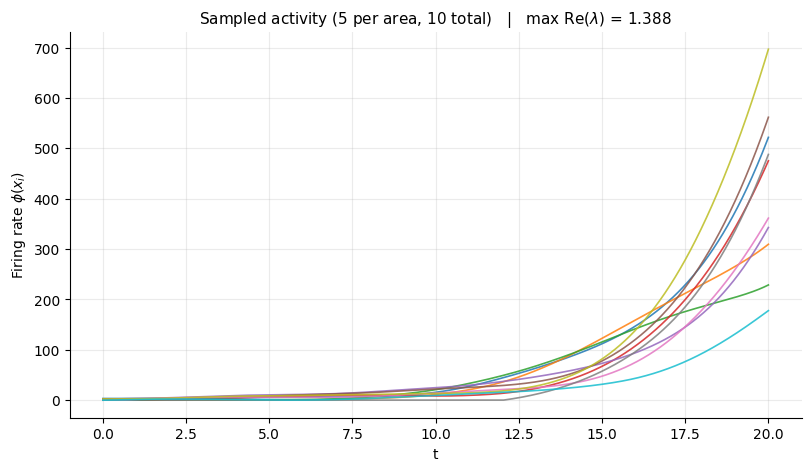

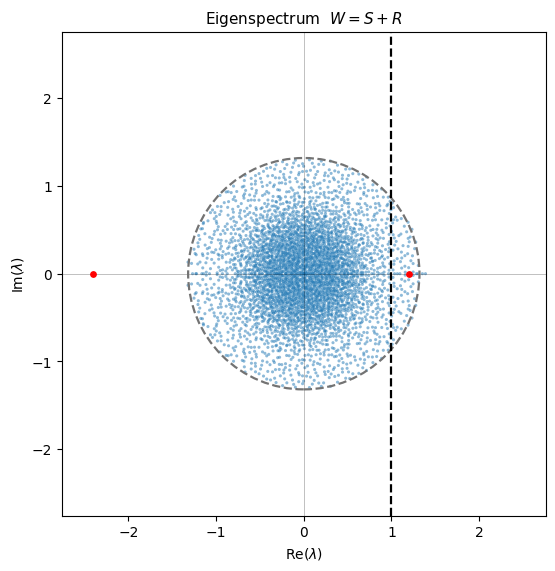

max Re(lambda) = 1.388   theoretical bulk radius r_R = 1.319


In [17]:
# ============================================================
#  >>> SET YOUR OWN 2-AREA PARAMETERS HERE <<<
#  Independent per-area + asymmetric cross-coupling
#  (same style as Multi-area_circuit_EI_sparse_scan_para.ipynb)
# ============================================================

# --- per-area parameters: area0 and area1 are INDEPENDENT -------------------
# Keep them identical for a symmetric network, or give them different
# N / s / f_exc / J_exc / g_inh for an ASYMMETRIC network.
area0 = AreaParams(N=2000, s=0.05, f_exc=0.8, J_exc=0.06, g_inh=4.5)
area1 = AreaParams(N=2000, s=0.05, f_exc=0.8, J_exc=0.06, g_inh=4.5)

# Example: asymmetric areas (uncomment to use)
# area0 = AreaParams(N=2000, s=0.05, f_exc=0.8, J_exc=0.06, g_inh=4.5)
# area1 = AreaParams(N=1500, s=0.06, f_exc=0.8, J_exc=0.04, g_inh=4.5)

# --- cross-area coupling: 2 x 2 matrices, convention  [src, tgt] ------------
#   entry [0, 1] = projection FROM area 0  TO area 1   (forward, 0 -> 1)
#   entry [1, 0] = projection FROM area 1  TO area 0   (backward, 1 -> 0)
#   set the two entries DIFFERENTLY for an asymmetric / feedforward network.
s_cross = np.zeros((2, 2))
s_cross[0, 1] = 0.025    # 0 -> 1 sparsity
s_cross[1, 0] = 0.025    # 1 -> 0 sparsity

J_cross = np.zeros((2, 2))
J_cross[0, 1] = 0.045     # 0 -> 1 weight
J_cross[1, 0] = 0.045     # 1 -> 0 weight

# Example: feedforward 0 -> 1 only (uncomment to use)
# s_cross[1, 0] = 0.0
# J_cross[1, 0] = 0.0
# Example: asymmetric strength, stronger 0 -> 1 than 1 -> 0 (uncomment to use)
# J_cross[0, 1] = 0.05
# J_cross[1, 0] = 0.01

# --- activation / integration ----------------------------------------------
activation = "threshold_linear"   # or "tanh"
gamma      = 0.5
phi_max    = np.inf   # finite -> saturating (keeps supra-threshold dynamics bounded);
                      # use np.inf for the non-saturating threshold-linear model
dt   = 0.005
T    = 20.0
seed = 0

# ---------------------------------------------------------------------------
p = MultiAreaParams(
    areas=(area0, area1),
    s_cross=s_cross,
    J_cross=J_cross,
    allow_autapses=False,
    activation=activation,
    phi_max=phi_max,
    gamma=gamma,
    dt=dt,
    T=T,
    seed=seed,
)

# Produces TWO figures: (A) the 10 sampled traces, (B) the standalone eigenspectrum.
# Initial-condition spread (so the 10 traces start visibly different):
#   - finite phi_max -> init_mode="uniform_rate", starting rates uniform in
#     [init_rate_low*phi_max, init_rate_high*phi_max]  (full [0, phi_max] by default)
#   - phi_max = inf  -> init_mode="normal_current", currents ~ N(0, init_current_scale^2)
out = plot_activity_and_spectrum(
    p,
    n_per_area=5,
    trace_seed=0,
    init_rate_low=0.0,        # widen for more initial spread (finite phi_max)
    init_rate_high=1.0,
    init_current_scale=3.0,   # widen for more initial spread (phi_max = inf)
)

print(f"max Re(lambda) = {out['max_re']:.3f}   theoretical bulk radius r_R = {out['R_theory']:.3f}")